In [13]:
import numpy as np
import matplotlib.pyplot as plt


In [14]:
X = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]).reshape(-1, 1)
y = np.array([0,   0,   0,   0,   0,   1,   0,   1,   1,   1,   1])

print(X.shape)


(11, 1)


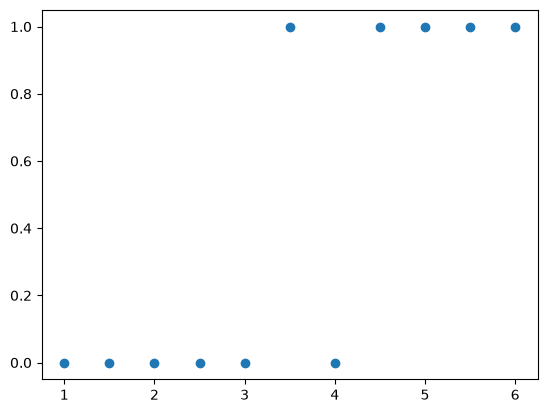

In [15]:
plt.scatter(X,y)
plt.show()

In [26]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    def fit(self, X, y):
        num_samples, num_feature = X.shape

        self.weights = np.zeros(num_feature)
        self.bias = 0

        for _ in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)

        y_predicted_cls = [1 if p > 0.5 else 0 for p in y_predicted]
        return np.array(y_predicted_cls)

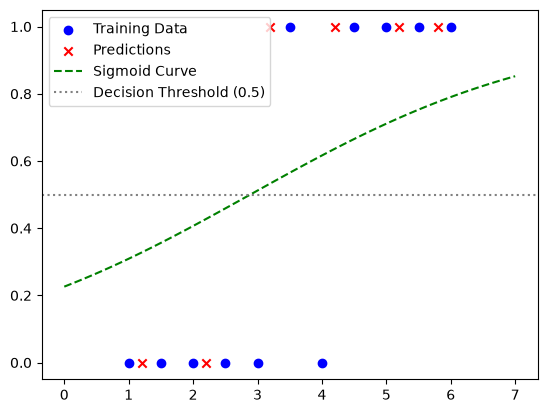

In [30]:
model = LogisticRegression()

model.fit(X, y)

X_test = np.array([1.2, 2.2, 3.2, 4.2, 5.2, 5.8]).reshape(-1, 1)
y_test = np.array([0, 0, 0, 1, 1, 1])

y_predict = model.predict(X_test)

plt.scatter(X, y, color='blue', label='Training Data')
plt.scatter(X_test, y_predict, color='red', marker='x', label='Predictions')

X_curve = np.linspace(0, 7, 100).reshape(-1, 1)
y_curve = model.predict_proba(X_curve)
plt.plot(X_curve, y_curve, color='green', linestyle='--', label='Sigmoid Curve')
plt.axhline(0.5, color='gray', linestyle=':', label='Decision Threshold (0.5)')
plt.legend()
plt.show()